Redox (/ˈrɛdɒks/ RED-oks, /ˈriːdɒks/ REE-doks, reduction–oxidation or oxidation–reduction ) is a type of chemical reaction in which the oxidation states of the reactants change. Oxidation is the loss of electrons or an increase in the oxidation state, while reduction is the gain of electrons or a decrease in the oxidation state. The oxidation and reduction processes occur simultaneously in the chemical reaction.

There are two classes of redox reactions:

Electron-transfer – Only one (usually) electron flows from the atom, ion, or molecule being oxidized to the atom, ion, or molecule that is reduced. This type of redox reaction is often discussed in terms of redox couples and electrode potentials.

Atom transfer – An atom transfers from one substrate to another. For example, in the rusting of iron, the oxidation state of iron atoms increases as the iron converts to an oxide, and simultaneously, the oxidation state of oxygen decreases as it accepts electrons released by the iron. Although oxidation reactions are commonly associated with forming oxides, other chemical species can serve the same function. In hydrogenation, bonds like C=C are reduced by transfer of hydrogen atoms.

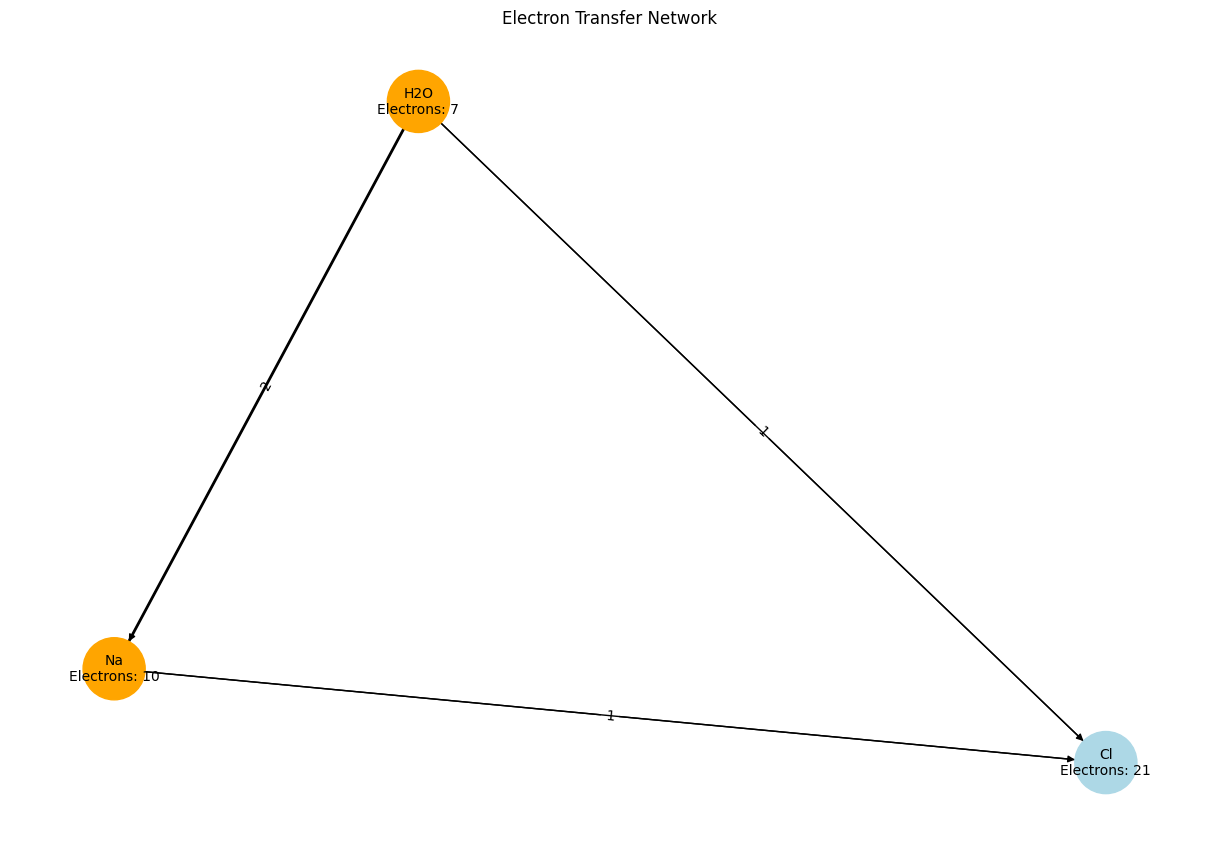


Reaction Log:

--- Round 1 ---

--- Round 2 ---
2 electrons transferred from H2O to Na.

--- Round 3 ---

--- Round 4 ---
2 electrons transferred from Na to Cl.

--- Round 5 ---
1 electrons transferred from H2O to Cl.

--- Round 6 ---
1 electrons transferred from Na to Cl.

--- Round 7 ---

--- Round 8 ---

--- Round 9 ---

--- Round 10 ---


In [ ]:
import networkx as nx
import matplotlib.pyplot as plt
import random

class ElectronTransferSimulation:
    def __init__(self):
        self.graph = nx.DiGraph()  # Directed graph to model the reaction network
        self.log = []  # Log for tracking electron transfers

    def add_species(self, species_name, electrons, oxidation_potential):
        """Add a chemical species with its number of electrons and oxidation potential."""
        self.graph.add_node(
            species_name,
            electrons=electrons,
            oxidation_potential=oxidation_potential
        )

    def transfer_electrons(self, donor, acceptor, num_electrons):
        """Simulate electron transfer from donor to acceptor."""
        if self.graph.nodes[donor]['electrons'] >= num_electrons:
            # Oxidation: donor loses electrons
            self.graph.nodes[donor]['electrons'] -= num_electrons

            # Reduction: acceptor gains electrons
            self.graph.nodes[acceptor]['electrons'] += num_electrons

            # Record the transfer
            self.graph.add_edge(donor, acceptor, weight=num_electrons)
            self.log.append(f"{num_electrons} electrons transferred from {donor} to {acceptor}.")
        else:
            self.log.append(f"Transfer failed: {donor} does not have enough electrons.")

    def simulate_reaction(self, rounds=10):
        """Run the electron transfer simulation for a number of rounds."""
        nodes = list(self.graph.nodes)

        for i in range(rounds):
            self.log.append(f"\n--- Round {i+1} ---")

            # Randomly select a donor and acceptor
            donor, acceptor = random.sample(nodes, 2)

            # Determine electron transfer based on oxidation potential
            donor_potential = self.graph.nodes[donor]['oxidation_potential']
            acceptor_potential = self.graph.nodes[acceptor]['oxidation_potential']

            if donor_potential > acceptor_potential:
                # Transfer electrons if donor is more oxidizing
                num_electrons = random.randint(1, min(3, self.graph.nodes[donor]['electrons']))
                self.transfer_electrons(donor, acceptor, num_electrons)

    def display_graph(self):
        """Visualize the network of electron transfers."""
        pos = nx.spring_layout(self.graph)
        edge_labels = nx.get_edge_attributes(self.graph, 'weight')
        node_labels = {node: f"{node}\nElectrons: {data['electrons']}"
                        for node, data in self.graph.nodes(data=True)}

        node_colors = ['lightblue' if data['oxidation_potential'] < 0 else 'orange'
                       for _, data in self.graph.nodes(data=True)]
        edge_widths = [data['weight'] for _, _, data in self.graph.edges(data=True)]

        plt.figure(figsize=(12, 8))
        nx.draw(self.graph, pos, with_labels=True, labels=node_labels,
                node_size=2000, node_color=node_colors, font_size=10)
        nx.draw_networkx_edge_labels(self.graph, pos, edge_labels=edge_labels)
        nx.draw_networkx_edges(self.graph, pos, width=edge_widths)
        plt.title("Electron Transfer Network")
        plt.show()

    def display_log(self):
        """Print the reaction log."""
        print("\nReaction Log:")
        for entry in self.log:
            print(entry)

# Example Usage
if __name__ == "__main__":
    # Create the electron transfer simulation
    reaction = ElectronTransferSimulation()

    # Add chemical species (name, initial electrons, oxidation potential)
    reaction.add_species("Na", electrons=11, oxidation_potential=0.5)  # Sodium
    reaction.add_species("Cl", electrons=17, oxidation_potential=-0.2)  # Chlorine
    reaction.add_species("H2O", electrons=10, oxidation_potential=1.23)  # Water

    # Simulate the reaction for 10 rounds
    reaction.simulate_reaction(rounds=10)

    # Display the system
    reaction.display_graph()
    reaction.display_log()

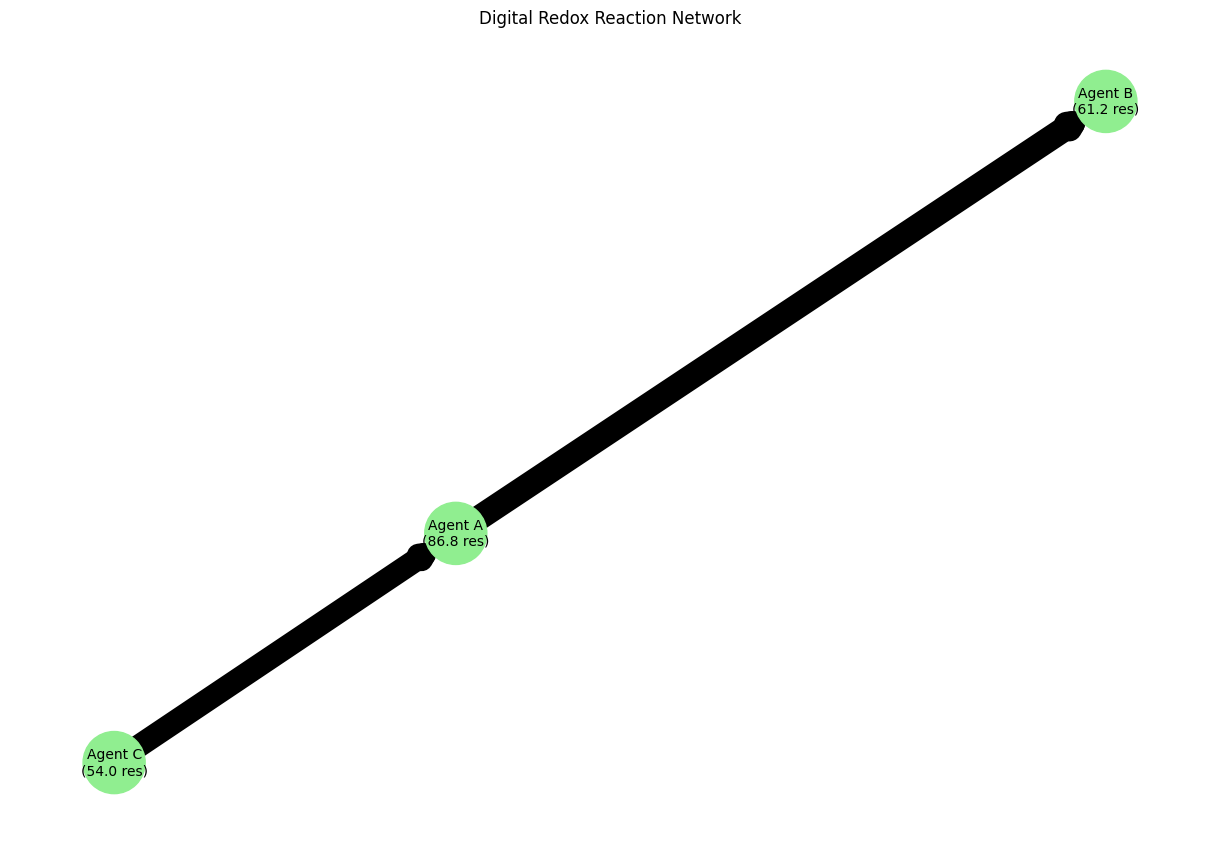


Transaction Log:
20 resources transferred from Agent A to Agent B (effective: 18.00).
15 resources transferred from Agent C to Agent A (effective: 16.50).
Applied resource decay with rate 0.1.


In [ ]:
import networkx as nx
import matplotlib.pyplot as plt

class DigitalRedoxReaction:
    def __init__(self):
        self.graph = nx.DiGraph()  # Directed graph to track resource flow
        self.log = []  # Log for tracking transactions

    def add_agent(self, agent_name, initial_resources, efficiency=1.0, priority=0):
        """Add an agent with resources, efficiency, and priority."""
        self.graph.add_node(
            agent_name,
            resources=initial_resources,
            efficiency=efficiency,
            priority=priority
        )

    def transfer_resource(self, donor, acceptor, amount):
        """Simulate a resource transfer (redox reaction)."""
        if self.graph.nodes[donor]['resources'] >= amount:
            # Adjust amount by donor's efficiency
            effective_amount = amount * self.graph.nodes[donor]['efficiency']

            # Oxidation: donor loses resources
            self.graph.nodes[donor]['resources'] -= amount
            # Reduction: acceptor gains resources
            self.graph.nodes[acceptor]['resources'] += effective_amount

            # Record the transfer
            self.graph.add_edge(donor, acceptor, weight=effective_amount)
            self.log.append(f"{amount} resources transferred from {donor} to {acceptor} (effective: {effective_amount:.2f}).")
        else:
            self.log.append(f"Transfer failed: {donor} does not have enough resources.")

    def decay_resources(self, decay_rate=0.05):
        """Apply resource decay to all agents."""
        for node in self.graph.nodes:
            resources = self.graph.nodes[node]['resources']
            decayed_resources = max(resources - decay_rate * resources, 0)
            self.graph.nodes[node]['resources'] = decayed_resources
        self.log.append(f"Applied resource decay with rate {decay_rate}.")

    def automated_transfers(self, threshold=50):
        """Automatically transfer resources from high-resource agents to low-resource ones."""
        sorted_agents = sorted(self.graph.nodes(data=True), key=lambda x: x[1]['resources'])
        for donor, acceptor in zip(sorted_agents[::-1], sorted_agents):
            donor_name, donor_data = donor
            acceptor_name, acceptor_data = acceptor
            if donor_data['resources'] > threshold and acceptor_data['resources'] < threshold:
                transfer_amount = min(donor_data['resources'] - threshold, threshold - acceptor_data['resources'])
                self.transfer_resource(donor_name, acceptor_name, transfer_amount)

    def display_graph(self):
        """Visualize the graph of agents and resource transfers."""
        pos = nx.spring_layout(self.graph)
        edge_labels = nx.get_edge_attributes(self.graph, 'weight')
        node_labels = {node: f"{node}\n({data['resources']:.1f} res)"
                        for node, data in self.graph.nodes(data=True)}

        node_colors = ['lightgreen' if data['resources'] > 50 else 'salmon'
                       for _, data in self.graph.nodes(data=True)]
        edge_widths = [data['weight'] for _, _, data in self.graph.edges(data=True)]

        plt.figure(figsize=(12, 8))
        nx.draw(self.graph, pos, with_labels=True, labels=node_labels,
                node_size=2000, node_color=node_colors, font_size=10)
        nx.draw_networkx_edge_labels(self.graph, pos, edge_labels=edge_labels)
        nx.draw_networkx_edges(self.graph, pos, width=edge_widths)
        plt.title("Digital Redox Reaction Network")
        plt.show()

    def display_log(self):
        """Print the transaction log."""
        print("\nTransaction Log:")
        for entry in self.log:
            print(entry)

# Example Usage
if __name__ == "__main__":
    # Create the digital redox reaction system
    redox_system = DigitalRedoxReaction()

    # Add agents with efficiency and priority
    redox_system.add_agent("Agent A", initial_resources=100, efficiency=0.9, priority=1)
    redox_system.add_agent("Agent B", initial_resources=50, efficiency=1.0, priority=2)
    redox_system.add_agent("Agent C", initial_resources=75, efficiency=1.1, priority=3)

    # Perform resource transfers (digital redox reactions)
    redox_system.transfer_resource("Agent A", "Agent B", 20)
    redox_system.transfer_resource("Agent C", "Agent A", 15)

    # Apply resource decay
    redox_system.decay_resources(decay_rate=0.1)

    # Perform automated transfers
    redox_system.automated_transfers(threshold=50)

    # Display the system
    redox_system.display_graph()
    redox_system.display_log()

**How It Works**

Node Initialization:

Nodes represent servers in a cloud network, each with a workload and a capacity.
Initial workloads are assigned randomly.
Workload Balancing:

Nodes exceeding the overload threshold transfer excess workload to underloaded nodes.
Transfers are limited by the sender's workload and the receiver's available capacity.
Simulation:

Each round involves identifying overloaded and underloaded nodes and redistributing workloads to minimize imbalance.
Visualization:

Nodes are color-coded:
Green: Below threshold.
Red: Overloaded.
Edges show workload transfers between nodes, with edge widths proportional to the transfer amounts.

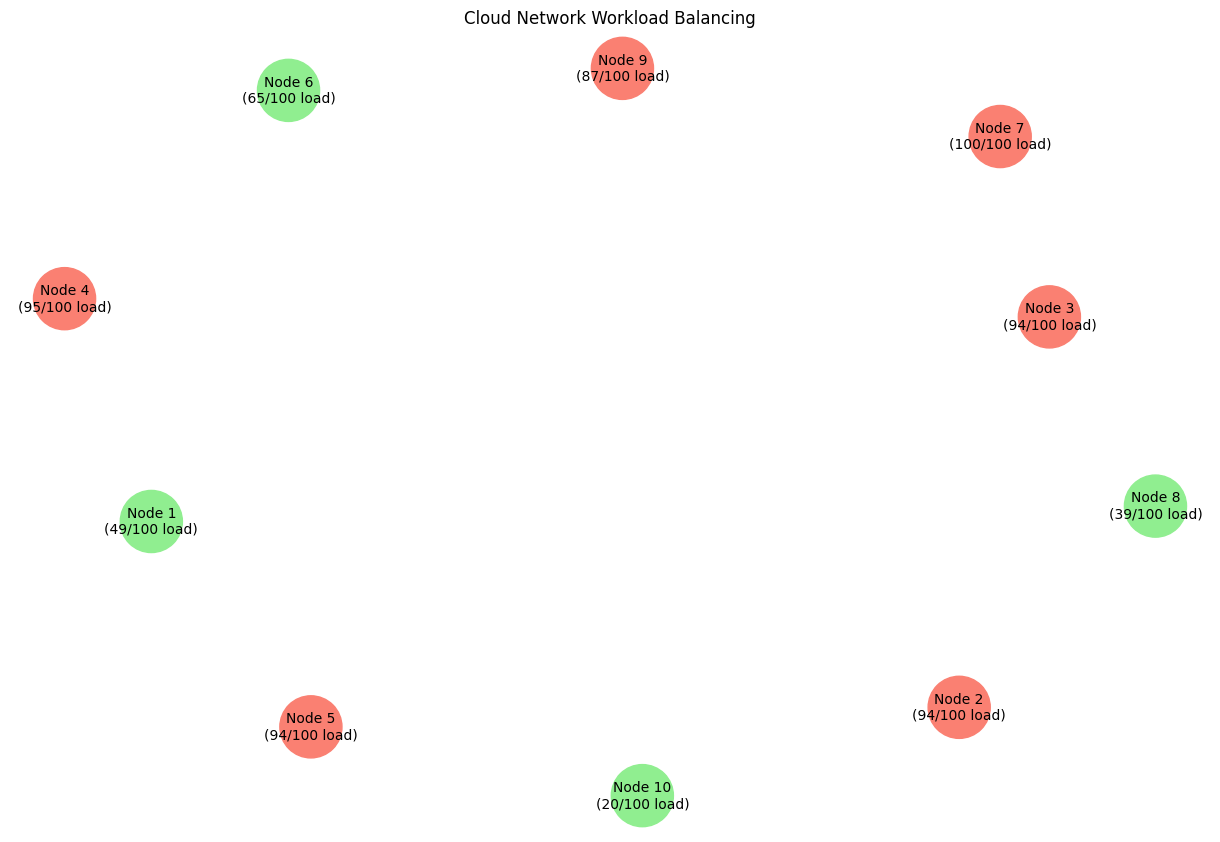


Simulation Log:

--- Round 1 ---

--- Round 2 ---

--- Round 3 ---

--- Round 4 ---

--- Round 5 ---

--- Round 6 ---

--- Round 7 ---

--- Round 8 ---

--- Round 9 ---

--- Round 10 ---


In [ ]:
import networkx as nx
import matplotlib.pyplot as plt
import random

class CloudNetworkSimulation:
    def __init__(self, num_nodes, max_capacity):
        self.graph = nx.DiGraph()  # Directed graph to model the network
        self.max_capacity = max_capacity  # Maximum capacity for each node
        self.log = []  # Log for tracking workload transfers

        # Initialize nodes with random workloads
        for i in range(num_nodes):
            node_name = f"Node {i+1}"
            initial_workload = random.randint(0, max_capacity)
            self.graph.add_node(node_name, workload=initial_workload, capacity=max_capacity)

    def transfer_workload(self, source, target, amount):
        """Simulate transferring workload from source to target."""
        if self.graph.nodes[source]['workload'] >= amount and \
           self.graph.nodes[target]['workload'] + amount <= self.graph.nodes[target]['capacity']:
            # Transfer workload
            self.graph.nodes[source]['workload'] -= amount
            self.graph.nodes[target]['workload'] += amount

            # Record the transfer
            self.graph.add_edge(source, target, weight=amount)
            self.log.append(f"{amount} workload transferred from {source} to {target}.")
        else:
            self.log.append(f"Transfer failed from {source} to {target}: insufficient capacity or workload.")

    def balance_workloads(self, threshold=0.8):
        """Distribute workloads to balance the network."""
        overloaded_nodes = [node for node, data in self.graph.nodes(data=True)
                            if data['workload'] > threshold * data['capacity']]
        underloaded_nodes = [node for node, data in self.graph.nodes(data=True)
                             if data['workload'] < (1 - threshold) * data['capacity']]

        for source in overloaded_nodes:
            for target in underloaded_nodes:
                source_workload = self.graph.nodes[source]['workload']
                target_capacity = self.graph.nodes[target]['capacity']
                target_workload = self.graph.nodes[target]['workload']

                # Calculate transferable workload
                transferable = min(source_workload - threshold * self.graph.nodes[source]['capacity'],
                                   (1 - threshold) * target_capacity - target_workload)
                if transferable > 0:
                    self.transfer_workload(source, target, int(transferable))

    def simulate(self, rounds=10, threshold=0.8):
        """Run the simulation for a number of rounds."""
        for i in range(rounds):
            self.log.append(f"\n--- Round {i+1} ---")
            self.balance_workloads(threshold=threshold)

    def display_graph(self):
        """Visualize the network and workloads."""
        pos = nx.spring_layout(self.graph)
        edge_labels = nx.get_edge_attributes(self.graph, 'weight')
        node_labels = {node: f"{node}\n({data['workload']}/{data['capacity']} load)"
                        for node, data in self.graph.nodes(data=True)}

        node_colors = ['lightgreen' if data['workload'] < 0.8 * data['capacity'] else 'salmon'
                       for _, data in self.graph.nodes(data=True)]
        edge_widths = [data['weight'] / 10 for _, _, data in self.graph.edges(data=True)]

        plt.figure(figsize=(12, 8))
        nx.draw(self.graph, pos, with_labels=True, labels=node_labels,
                node_size=2000, node_color=node_colors, font_size=10)
        nx.draw_networkx_edge_labels(self.graph, pos, edge_labels=edge_labels)
        nx.draw_networkx_edges(self.graph, pos, width=edge_widths)
        plt.title("Cloud Network Workload Balancing")
        plt.show()

    def display_log(self):
        """Print the simulation log."""
        print("\nSimulation Log:")
        for entry in self.log:
            print(entry)

# Example Usage
if __name__ == "__main__":
    # Create a cloud network simulation with 10 nodes and a max capacity of 100 per node
    cloud_network = CloudNetworkSimulation(num_nodes=10, max_capacity=100)

    # Run the simulation for 10 rounds
    cloud_network.simulate(rounds=10, threshold=0.8)

    # Display the network and log
    cloud_network.display_graph()
    cloud_network.display_log()

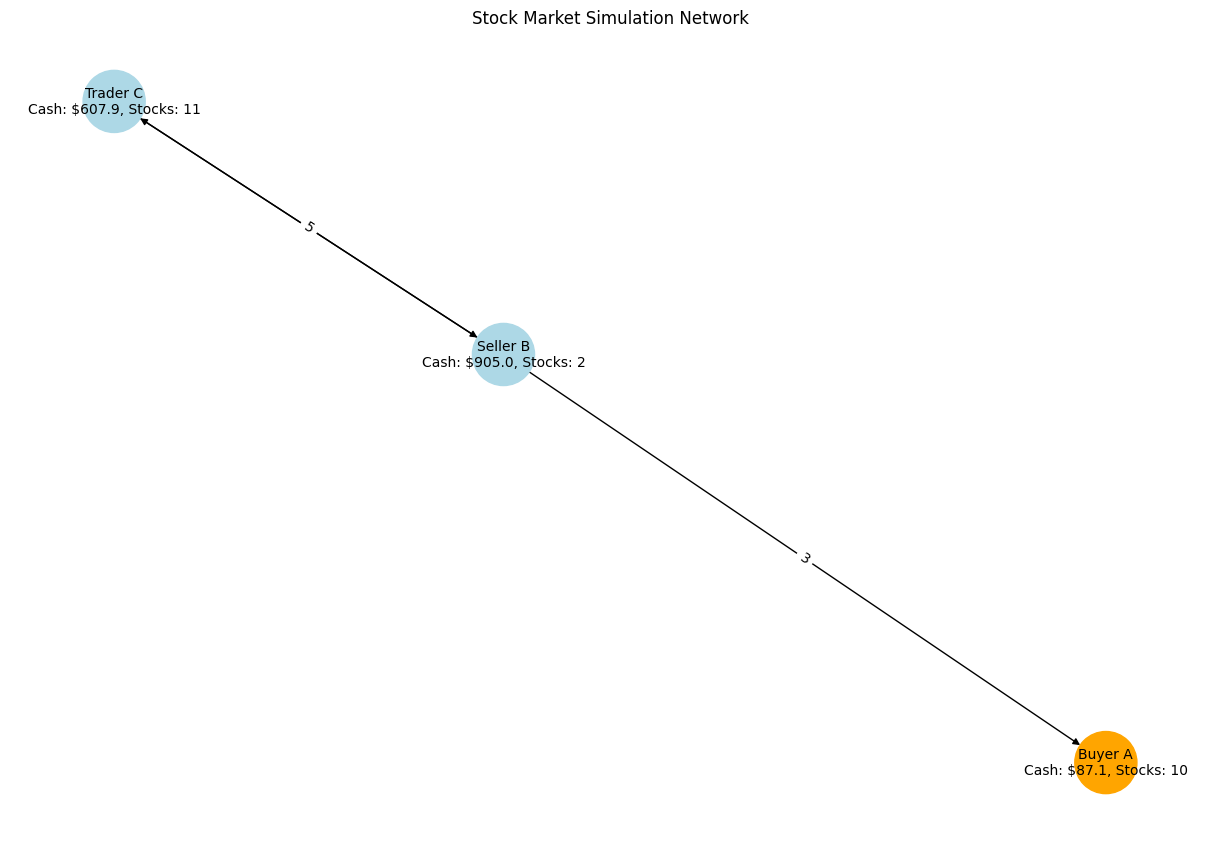


Market Transaction Log:
2 stocks traded from Trader C to Seller B at $100 each.
Stock price adjusted to $95.0.
1 stocks traded from Seller B to Buyer A at $95.0 each.
Stock price adjusted to $90.25.
Trade failed between Buyer A and Seller B: insufficient resources.
Stock price adjusted to $85.74.
1 stocks traded from Seller B to Buyer A at $85.74 each.
Stock price adjusted to $81.45.
1 stocks traded from Seller B to Trader C at $81.45 each.
Stock price adjusted to $77.38.
3 stocks traded from Seller B to Buyer A at $77.38 each.
Stock price adjusted to $73.51.
4 stocks traded from Seller B to Trader C at $73.51 each.
Stock price adjusted to $69.83.
Trade failed between Buyer A and Seller B: insufficient resources.
Stock price adjusted to $66.34.
5 stocks traded from Trader C to Seller B at $66.34 each.
Stock price adjusted to $69.66.
5 stocks traded from Seller B to Trader C at $69.66 each.
Stock price adjusted to $66.18.


In [ ]:
import networkx as nx
import matplotlib.pyplot as plt
import random

class StockMarketSimulation:
    def __init__(self, initial_price=100):
        self.graph = nx.DiGraph()  # Directed graph to track market agents and trades
        self.stock_price = initial_price  # Initial stock price
        self.log = []  # Log for market transactions

    def add_agent(self, agent_name, cash, stocks):
        """Add a buyer or seller with initial cash and stocks."""
        self.graph.add_node(agent_name, cash=cash, stocks=stocks)

    def trade(self, buyer, seller, quantity):
        """Simulate a trade between a buyer and a seller."""
        cost = self.stock_price * quantity
        if self.graph.nodes[buyer]['cash'] >= cost and self.graph.nodes[seller]['stocks'] >= quantity:
            # Transfer stocks and cash
            self.graph.nodes[buyer]['cash'] -= cost
            self.graph.nodes[seller]['cash'] += cost
            self.graph.nodes[buyer]['stocks'] += quantity
            self.graph.nodes[seller]['stocks'] -= quantity

            # Record the transaction
            self.graph.add_edge(seller, buyer, weight=quantity)
            self.log.append(f"{quantity} stocks traded from {seller} to {buyer} at ${self.stock_price} each.")
        else:
            self.log.append(f"Trade failed between {buyer} and {seller}: insufficient resources.")

    def adjust_stock_price(self):
        """Adjust stock price based on supply and demand."""
        total_stocks = sum(data['stocks'] for _, data in self.graph.nodes(data=True))
        total_cash = sum(data['cash'] for _, data in self.graph.nodes(data=True))

        # Price increases if demand (cash) > supply (stocks), and vice versa
        if total_cash > total_stocks * self.stock_price:
            self.stock_price *= 1.05  # 5% increase
        elif total_cash < total_stocks * self.stock_price:
            self.stock_price *= 0.95  # 5% decrease
        self.stock_price = max(1, round(self.stock_price, 2))  # Ensure price is always positive

        self.log.append(f"Stock price adjusted to ${self.stock_price}.")

    def simulate_market(self, rounds=10):
        """Run the stock market simulation for a number of rounds."""
        agents = list(self.graph.nodes)
        for _ in range(rounds):
            # Randomly pick a buyer and a seller
            buyer, seller = random.sample(agents, 2)
            quantity = random.randint(1, 5)  # Random trade quantity
            self.trade(buyer, seller, quantity)

            # Adjust stock price after each round
            self.adjust_stock_price()

    def display_graph(self):
        """Visualize the graph of agents and trades."""
        pos = nx.spring_layout(self.graph)
        edge_labels = nx.get_edge_attributes(self.graph, 'weight')
        node_labels = {node: f"{node}\nCash: ${data['cash']:.1f}, Stocks: {data['stocks']}"
                        for node, data in self.graph.nodes(data=True)}

        node_colors = ['lightblue' if data['cash'] > 100 else 'orange'
                       for _, data in self.graph.nodes(data=True)]

        plt.figure(figsize=(12, 8))
        nx.draw(self.graph, pos, with_labels=True, labels=node_labels,
                node_size=2000, node_color=node_colors, font_size=10)
        nx.draw_networkx_edge_labels(self.graph, pos, edge_labels=edge_labels)
        plt.title("Stock Market Simulation Network")
        plt.show()

    def display_log(self):
        """Print the market transaction log."""
        print("\nMarket Transaction Log:")
        for entry in self.log:
            print(entry)

# Example Usage
if __name__ == "__main__":
    # Create the stock market simulation
    market = StockMarketSimulation(initial_price=100)

    # Add agents (buyers and sellers)
    market.add_agent("Buyer A", cash=500, stocks=5)
    market.add_agent("Seller B", cash=300, stocks=10)
    market.add_agent("Trader C", cash=800, stocks=8)

    # Run the simulation for 10 rounds
    market.simulate_market(rounds=10)

    # Display the system
    market.display_graph()
    market.display_log()

**How It Works**

Agents:

Each agent starts with a specified amount of cash and stocks.
Trading Rules:

A buyer can only purchase stocks if they have enough cash.
A seller can only sell stocks if they own enough shares.
Dynamic Stock Pricing:

The stock price fluctuates based on a simple supply-and-demand metric:
Price increases if cash > stock value.
Price decreases if cash < stock value.
Simulation:

Random buyers and sellers are selected for trades in each round.
Transactions and price adjustments occur iteratively.
Visualization:

The graph shows agent resources (cash and stocks) and trade activity.